# 2. Evaluation

In [5]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [6]:
import torch

In [16]:
from src.model import FER2013CNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FER2013CNN()  # recria arquitetura

state_dict = torch.load(
    "../checkpoints/best_model.pt",
    map_location=device
)

model.load_state_dict(state_dict)
model.to(device)
model.eval()

FER2013CNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=4608, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=7, bias=True)
)

In [34]:
from src.data import FER2013Dataset, val_test_transform, get_dataloader

test_dataset = FER2013Dataset(split='test', transform=val_test_transform)
test_loader = get_dataloader(test_dataset)

In [35]:
ground_truths = []
predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predicted = outputs.argmax(dim=1)

        ground_truths.extend(labels.cpu().tolist())
        predictions.extend(predicted.cpu().tolist())

In [40]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    ground_truths, predictions
    ))

              precision    recall  f1-score   support

           0       0.45      0.48      0.47       958
           1       0.75      0.42      0.54       111
           2       0.43      0.38      0.41      1024
           3       0.77      0.77      0.77      1774
           4       0.47      0.52      0.50      1233
           5       0.42      0.44      0.43      1247
           6       0.78      0.67      0.72       831

    accuracy                           0.56      7178
   macro avg       0.58      0.53      0.55      7178
weighted avg       0.57      0.56      0.56      7178



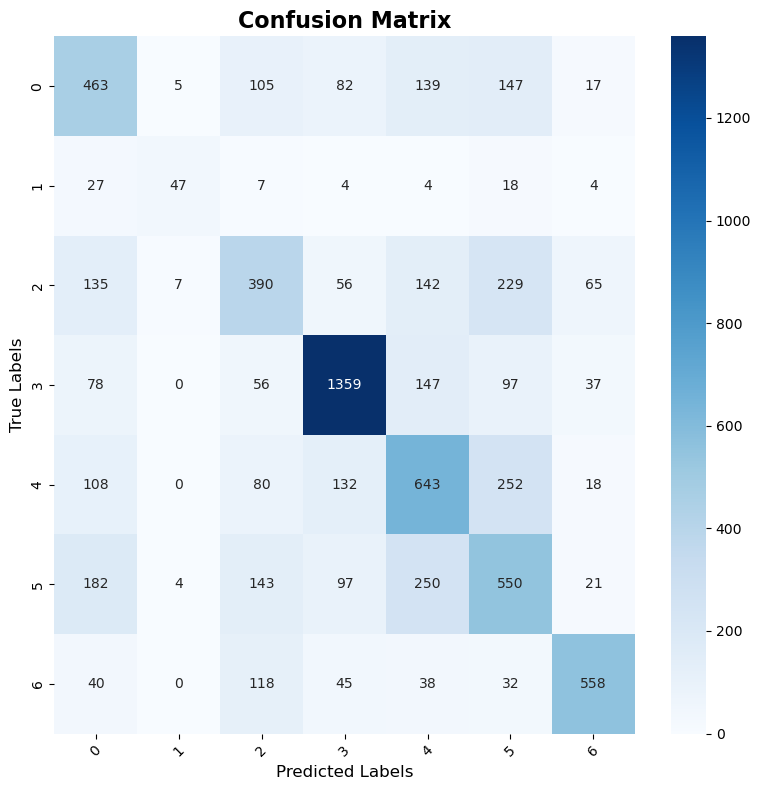

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    confusion_matrix(ground_truths, predictions),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax
)

ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted Labels', fontsize=12)
ax.set_ylabel('True Labels', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()